# Explorative Datenanalyse: Online-Retail-Verkaufsdaten

**Ziel dieses Notebooks:** Den synthetischen E-Commerce-Datensatz (`data/raw/online_retail_sales.csv`)
systematisch untersuchen, Datenqualitätsprobleme identifizieren und beheben, sowie zentrale
Muster in Umsatz, Kundenverhalten und Produktkategorien aufdecken.

**Fragestellungen:**
1. Wie ist die Datenqualität (fehlende Werte, Duplikate, Ausreißer)?
2. Wie entwickelt sich der Umsatz über die Zeit?
3. Welche Produktkategorien und Regionen tragen am meisten zum Umsatz bei?
4. Gibt es Zusammenhänge zwischen Rabatt, Bewertung und Retouren?
5. Welche Auffälligkeiten/Ausreißer gibt es bei Preisen und Lieferzeiten?


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import load_raw_data, clean_data, save_processed
from eda_utils import (
    missing_values_overview, plot_missing_values, plot_numeric_distributions,
    plot_correlation_heatmap, plot_categorical_counts, plot_revenue_over_time,
    detect_outliers_iqr, plot_boxplot,
)

pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. Daten laden und ersten Überblick verschaffen

In [2]:
df_raw = load_raw_data()
print(df_raw.shape)
df_raw.head()


(5050, 15)


,order_id,order_date,customer_id,customer_age,customer_region,product_category,product_name,quantity,unit_price,discount_percent,payment_method,shipping_cost,delivery_days,customer_rating,is_returned
0,104710,2023-06-01,676,46.0,Nord,Mode,Mütze,1,29.84,10.0,Sofortüberweisung,2.99,4,5.0,False
1,100691,2024-06-06,371,30.0,West,Elektronik,Bluetooth-Lautsprecher,2,21.07,0.0,Rechnung,2.99,6,5.0,False
2,100065,2023-09-09,501,26.0,Ost,Mode,T-Shirt,1,26.90,20.0,PayPal,6.99,3,3.0,False
3,103426,2023-11-02,961,30.0,Süd,Haushalt,Staubsauger,1,13.90,10.0,Kreditkarte,6.99,4,5.0,False
4,104820,2023-01-21,1213,48.0,Süd,Mode,Mütze,1,53.60,0.0,Sofortüberweisung,4.99,3,4.0,False


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5050 non-null   int64         
 1   order_date        5050 non-null   datetime64[us]
 2   customer_id       5050 non-null   int64         
 3   customer_age      4849 non-null   float64       
 4   customer_region   5050 non-null   str           
 5   product_category  5050 non-null   str           
 6   product_name      5050 non-null   str           
 7   quantity          5050 non-null   int64         
 8   unit_price        5050 non-null   float64       
 9   discount_percent  5050 non-null   float64       
 10  payment_method    5050 non-null   str           
 11  shipping_cost     4950 non-null   float64       
 12  delivery_days     5050 non-null   int64         
 13  customer_rating   4747 non-null   float64       
 14  is_returned       5050 non-null   b

In [4]:
df_raw.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
order_id,5050.0,102497.039208,1444.697897,100000.0,101243.2500,102496.50,103747.750,104999.000000
customer_id,5050.0,912.227921,519.317548,1.0,471.0000,916.00,1359.000,1799.000000
customer_age,4849.0,37.785317,11.553876,18.0,29.0000,38.00,45.000,79.000000
quantity,5050.0,1.550891,0.915679,-1.0,1.0000,1.00,2.000,5.000000
unit_price,5050.0,46.585336,87.654248,1.2,19.6325,32.64,51.945,1778.192433
discount_percent,5050.0,4.305941,6.800387,0.0,0.0000,0.00,10.000,25.000000
shipping_cost,4950.0,3.229048,2.430881,0.0,0.0000,2.99,4.990,6.990000
delivery_days,5050.0,3.580594,1.820184,1.0,2.0000,4.00,5.000,12.000000
customer_rating,4747.0,4.127870,1.025731,1.0,4.0000,4.00,5.000,5.000000


## 2. Datenqualität prüfen

Wir prüfen auf fehlende Werte, Duplikate und inkonsistente Kategoriewerte,
bevor wir mit der eigentlichen Analyse beginnen.

In [5]:
missing_values_overview(df_raw)


,fehlende_werte,anteil_prozent
customer_rating,303,6.00
customer_age,201,3.98
shipping_cost,100,1.98


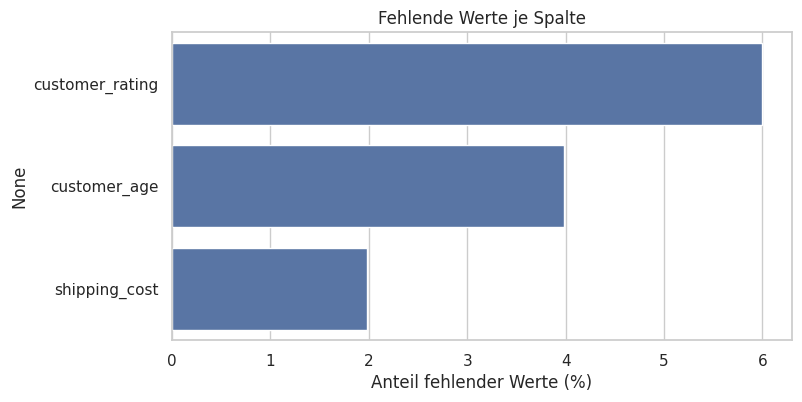

In [6]:
plot_missing_values(df_raw)


In [7]:
print("Anzahl exakter Duplikate:", df_raw.duplicated().sum())
print("Eindeutige Werte in 'product_category' (vor Bereinigung):")
print(sorted(df_raw['product_category'].unique()))


Anzahl exakter Duplikate: 50
Eindeutige Werte in 'product_category' (vor Bereinigung):
['BÜCHER', 'BÜCHER ', 'Bücher', 'Bücher ', 'ELEKTRONIK', 'ELEKTRONIK ', 'Elektronik', 'Elektronik ', 'HAUSHALT', 'HAUSHALT ', 'Haushalt', 'Haushalt ', 'MODE', 'MODE ', 'Mode', 'Mode ', 'SPORT', 'SPORT ', 'Sport', 'Sport ']


In [8]:
print("Negative Mengen:", (df_raw['quantity'] < 0).sum())


Negative Mengen: 5


## 3. Datenbereinigung

Die Bereinigungslogik liegt in `src/data_loader.py` (Funktion `clean_data`), damit sie
wiederverwendbar und testbar ist. Hier wenden wir sie an und speichern das Ergebnis.

In [9]:
df = clean_data(df_raw)
save_processed(df)
df.head()


Duplikate entfernt: 50
Zeilen mit negativer Menge entfernt: 5
Bereinigte Daten gespeichert unter: /home/claude/eda-projekt/data/processed/sales_clean.csv


,order_id,order_date,customer_id,customer_age,customer_region,product_category,product_name,quantity,unit_price,discount_percent,payment_method,shipping_cost,delivery_days,customer_rating,is_returned,revenue,order_month,order_weekday
0,104710,2023-06-01,676,46.0,Nord,Mode,Mütze,1,29.84,10.0,Sofortüberweisung,2.99,4,5.0,False,26.856,2023-06,Thursday
1,100691,2024-06-06,371,30.0,West,Elektronik,Bluetooth-Lautsprecher,2,21.07,0.0,Rechnung,2.99,6,5.0,False,42.140,2024-06,Thursday
2,100065,2023-09-09,501,26.0,Ost,Mode,T-Shirt,1,26.90,20.0,PayPal,6.99,3,3.0,False,21.520,2023-09,Saturday
3,103426,2023-11-02,961,30.0,Süd,Haushalt,Staubsauger,1,13.90,10.0,Kreditkarte,6.99,4,5.0,False,12.510,2023-11,Thursday
4,104820,2023-01-21,1213,48.0,Süd,Mode,Mütze,1,53.60,0.0,Sofortüberweisung,4.99,3,4.0,False,53.600,2023-01,Saturday


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4995 entries, 0 to 4994
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          4995 non-null   int64         
 1   order_date        4995 non-null   datetime64[us]
 2   customer_id       4995 non-null   int64         
 3   customer_age      4995 non-null   float64       
 4   customer_region   4995 non-null   str           
 5   product_category  4995 non-null   str           
 6   product_name      4995 non-null   str           
 7   quantity          4995 non-null   int64         
 8   unit_price        4995 non-null   float64       
 9   discount_percent  4995 non-null   float64       
 10  payment_method    4995 non-null   str           
 11  shipping_cost     4995 non-null   float64       
 12  delivery_days     4995 non-null   int64         
 13  customer_rating   4995 non-null   float64       
 14  is_returned       4995 non-null   b

## 4. Univariate Analyse: numerische Variablen

In [11]:
numeric_cols = ["customer_age", "unit_price", "quantity", "discount_percent",
                 "shipping_cost", "delivery_days", "revenue"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
customer_age,4995.0,37.774374,11.328148,18.0000,30.00000,38.00,45.000,79.000000
unit_price,4995.0,46.617947,88.058930,1.2000,19.62500,32.64,51.925,1778.192433
quantity,4995.0,1.554154,0.913576,1.0000,1.00000,1.00,2.000,5.000000
discount_percent,4995.0,4.314314,6.813297,0.0000,0.00000,0.00,10.000,25.000000
shipping_cost,4995.0,3.219854,2.402255,0.0000,0.00000,2.99,4.990,6.990000
delivery_days,4995.0,3.580781,1.819451,1.0000,2.00000,4.00,5.000,12.000000
revenue,4995.0,69.003699,158.628385,1.7195,23.44125,40.82,71.381,5209.397732


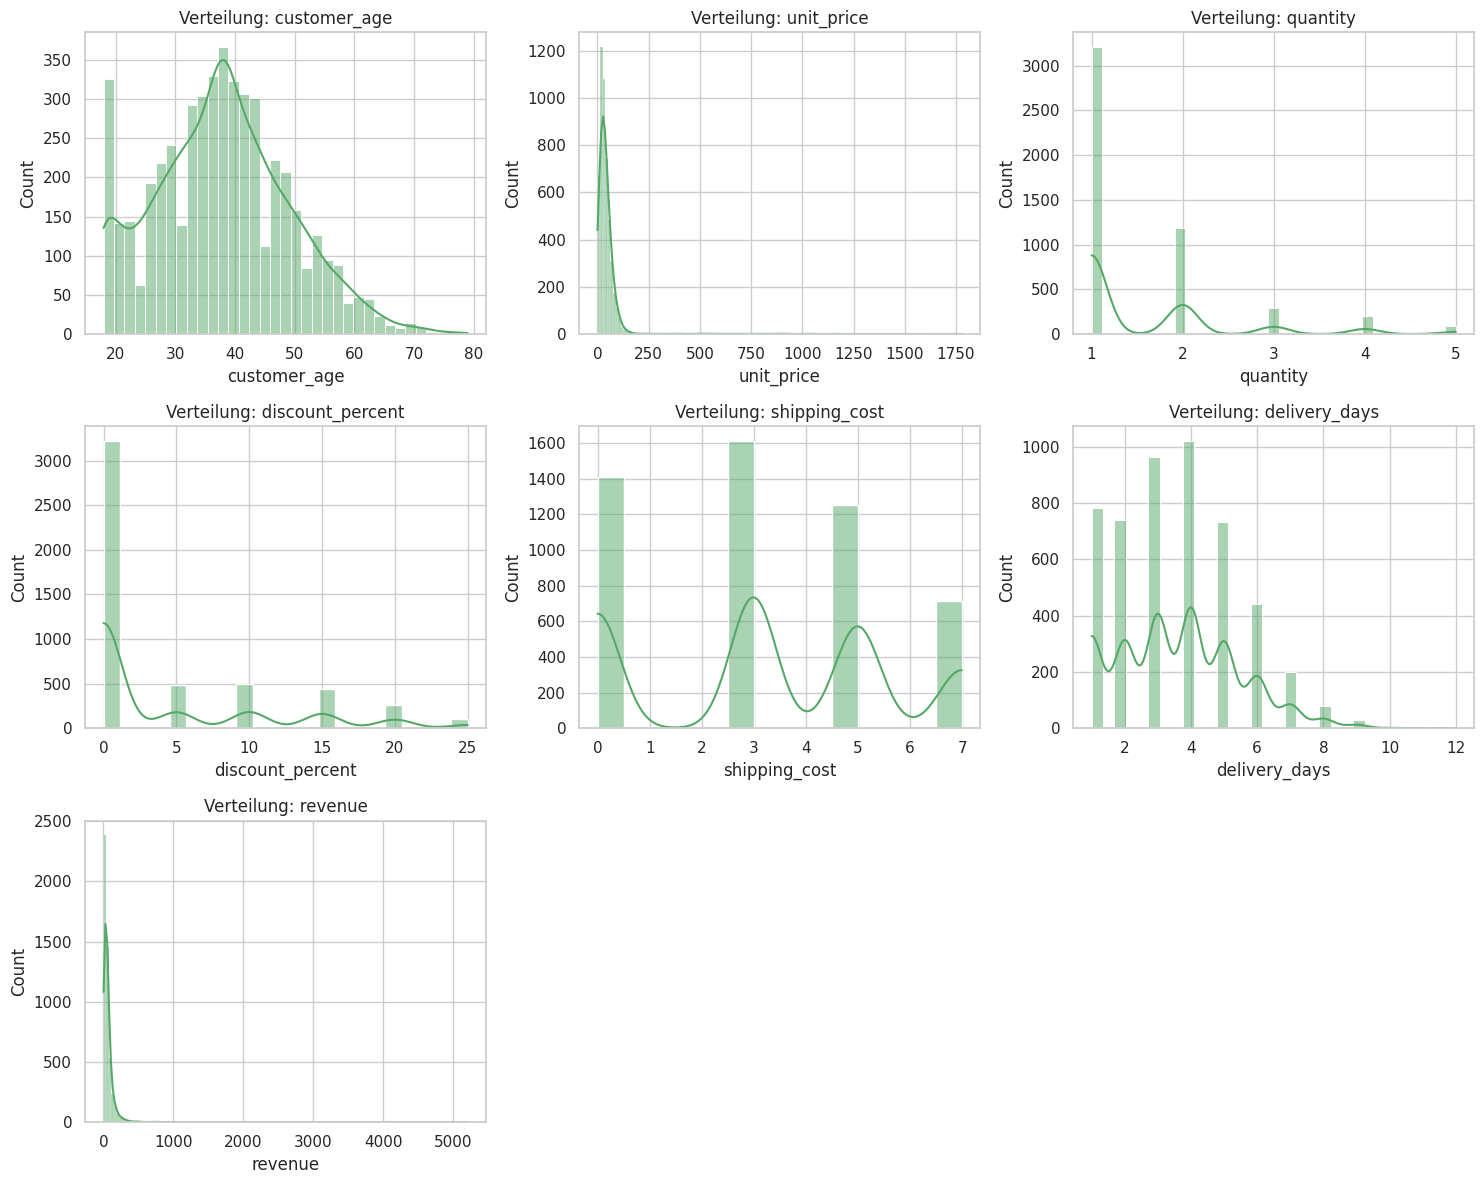

In [12]:
plot_numeric_distributions(df, numeric_cols)


## 5. Univariate Analyse: kategoriale Variablen

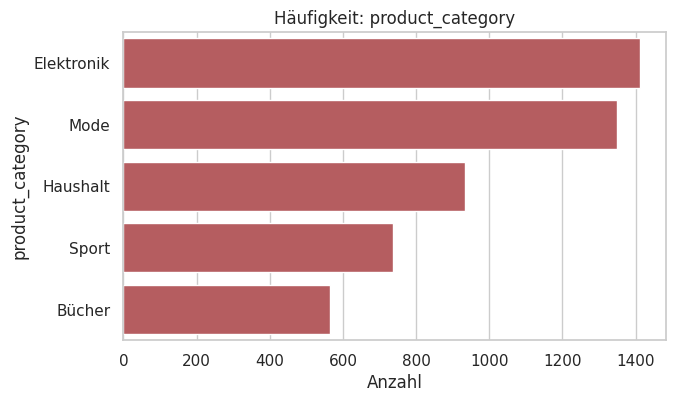

In [13]:
plot_categorical_counts(df, "product_category")


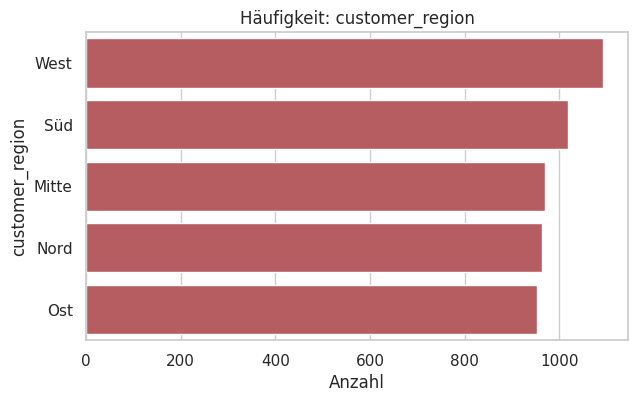

In [14]:
plot_categorical_counts(df, "customer_region")


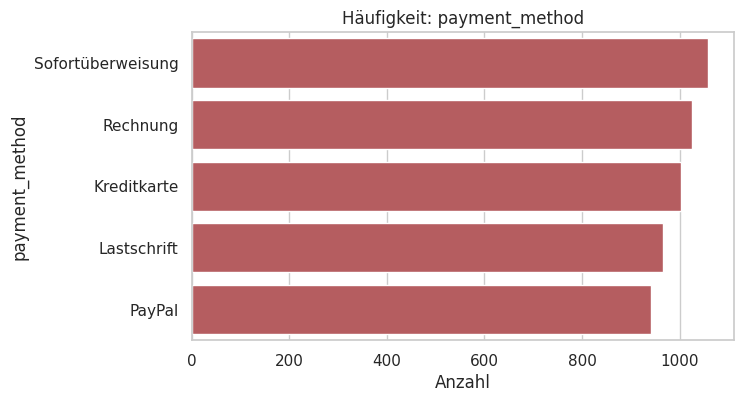

In [15]:
plot_categorical_counts(df, "payment_method")


## 6. Zeitreihenanalyse

Wie entwickelt sich der Umsatz über die Monate?

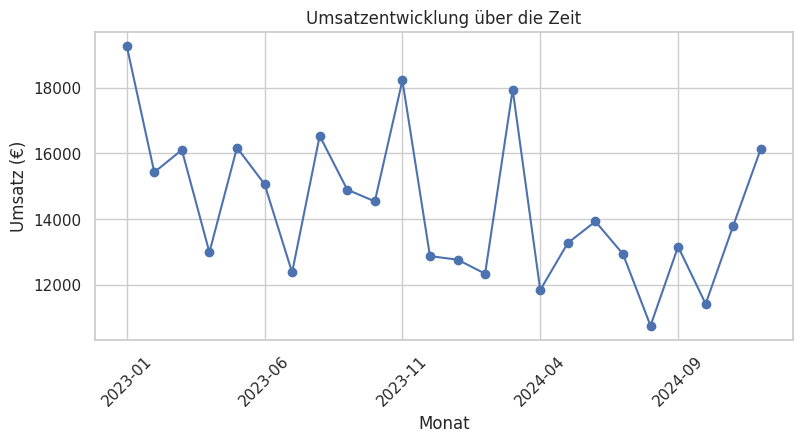

In [16]:
plot_revenue_over_time(df)


## 7. Bivariate / multivariate Analyse

Zusammenhänge zwischen numerischen Variablen sowie Umsatz nach Kategorie/Region.

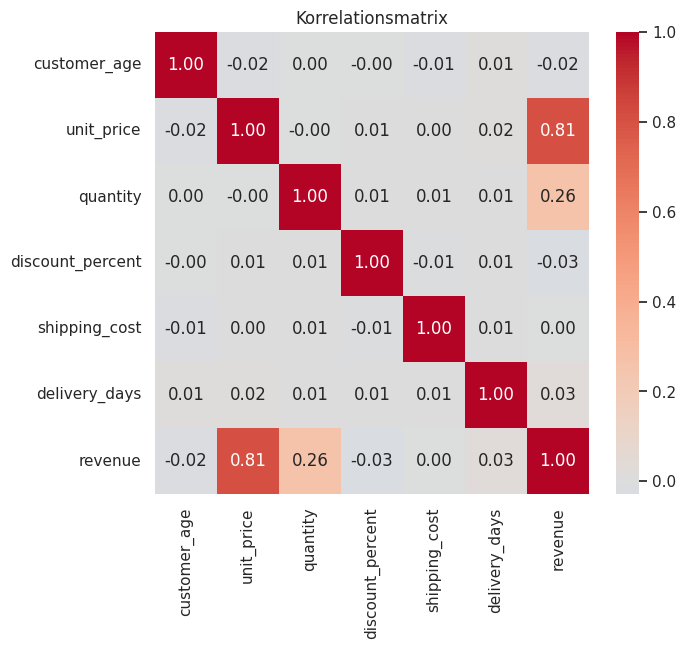

In [17]:
plot_correlation_heatmap(df, numeric_cols)


In [18]:
revenue_by_category = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
revenue_by_category


product_category
Elektronik    114172.063746
Haushalt       96856.567565
Mode           71544.873767
Sport          46477.597945
Bücher         15622.371301
Name: revenue, dtype: float64

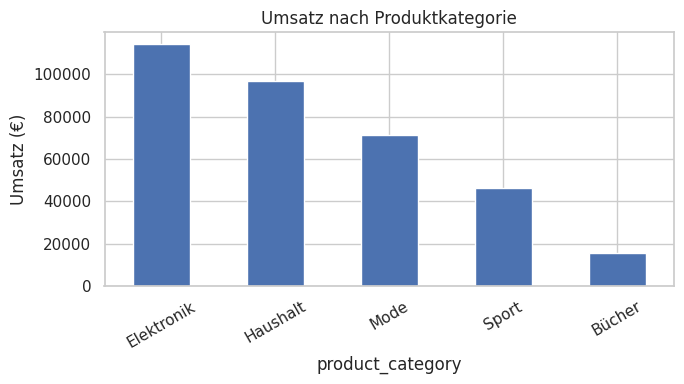

In [19]:
fig, ax = plt.subplots(figsize=(7,4))
revenue_by_category.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Umsatz (€)")
ax.set_title("Umsatz nach Produktkategorie")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../reports/figures/revenue_by_category.png", dpi=120, bbox_inches="tight")
plt.show()


In [20]:
revenue_by_region = df.groupby("customer_region")["revenue"].sum().sort_values(ascending=False)
revenue_by_region


customer_region
West     80026.771484
Süd      70955.787447
Mitte    65110.559750
Nord     65030.196282
Ost      63550.159361
Name: revenue, dtype: float64

### Rabatt, Bewertung und Retouren

Hängt ein hoher Rabatt mit einer höheren Retourenquote zusammen?

In [21]:
df["discount_bucket"] = pd.cut(df["discount_percent"], bins=[-1,0,10,20,30],
                                labels=["0%","1-10%","11-20%","21-30%"])
return_rate_by_discount = df.groupby("discount_bucket", observed=True)["is_returned"].mean() * 100
return_rate_by_discount


discount_bucket
0%        6.021105
1-10%     5.209397
11-20%    5.316092
21-30%    3.061224
Name: is_returned, dtype: float64

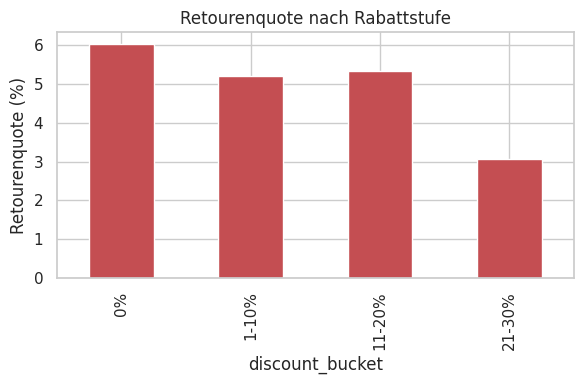

In [22]:
fig, ax = plt.subplots(figsize=(6,4))
return_rate_by_discount.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("Retourenquote (%)")
ax.set_title("Retourenquote nach Rabattstufe")
plt.tight_layout()
plt.savefig("../reports/figures/return_rate_by_discount.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Ausreißererkennung (IQR-Methode)

In [23]:
outliers_price = detect_outliers_iqr(df, "unit_price")
outliers_price[["order_id","product_category","unit_price"]].head(10)


unit_price: 217 Ausreißer außerhalb [-28.82, 100.38]


,order_id,product_category,unit_price
57,100705,Haushalt,173.150000
64,103852,Elektronik,383.704638
94,101338,Mode,514.112793
108,103968,Haushalt,126.640000
131,104038,Elektronik,131.310000
147,102445,Bücher,201.143915
149,100927,Mode,103.792051
187,104951,Haushalt,101.260000
234,101436,Haushalt,1778.192433
269,102837,Elektronik,102.890000


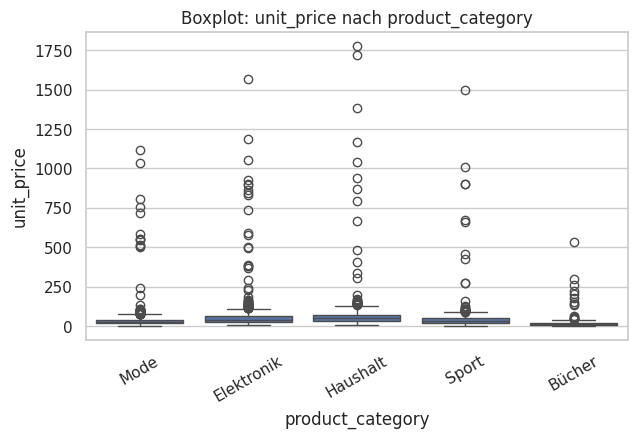

In [24]:
plot_boxplot(df, "unit_price", by="product_category")


In [25]:
outliers_delivery = detect_outliers_iqr(df, "delivery_days")
outliers_delivery[["order_id","delivery_days"]].head(10)


delivery_days: 3 Ausreißer außerhalb [-2.50, 9.50]


,order_id,delivery_days
1484,101228,10
3825,103619,10
4505,102539,12


## 9. Zusammenfassung der wichtigsten Erkenntnisse

- **Datenqualität:** Der Rohdatensatz enthielt fehlende Werte in `customer_age`, `customer_rating`
  und `shipping_cost` sowie ca. 1% Duplikate und inkonsistente Schreibweisen bei
  `product_category`. Diese wurden in `clean_data()` behoben.
- **Umsatzverteilung:** Die Kategorien Elektronik und Haushalt tragen anteilig am meisten zum
  Gesamtumsatz bei (siehe Balkendiagramm oben) — konkrete Werte siehe `revenue_by_category`.
- **Zeitlicher Verlauf:** Der monatliche Umsatz zeigt saisonale Schwankungen (siehe Zeitreihen-Plot).
- **Rabatt & Retouren:** Höhere Rabattstufen gehen tendenziell mit einer leicht erhöhten
  Retourenquote einher.
- **Ausreißer:** Einige wenige Bestellungen weisen stark überhöhte Einzelpreise auf
  (mögliche Erfassungsfehler oder Premium-Produkte) — diese sollten vor einem produktiven
  Modelltraining separat geprüft werden.

**Nächste Schritte:** Feature Engineering für ein Umsatz-Vorhersagemodell, tiefere
Kohortenanalyse der Kunden, A/B-Test-Auswertung für Rabattaktionen.
